In [1]:
import pandas as pd

df = pd.read_csv("laptop_data.csv")

print(df.head())
print(df.info())
print(df.shape)

   Unnamed: 0 Company   TypeName  Inches                    ScreenResolution  \
0           0   Apple  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   
1           1   Apple  Ultrabook    13.3                            1440x900   
2           2      HP   Notebook    15.6                   Full HD 1920x1080   
3           3   Apple  Ultrabook    15.4  IPS Panel Retina Display 2880x1800   
4           4   Apple  Ultrabook    13.3  IPS Panel Retina Display 2560x1600   

                          Cpu   Ram               Memory  \
0        Intel Core i5 2.3GHz   8GB            128GB SSD   
1        Intel Core i5 1.8GHz   8GB  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz   8GB            256GB SSD   
3        Intel Core i7 2.7GHz  16GB            512GB SSD   
4        Intel Core i5 3.1GHz   8GB            256GB SSD   

                            Gpu  OpSys  Weight        Price  
0  Intel Iris Plus Graphics 640  macOS  1.37kg   71378.6832  
1        Intel HD Graphics 6000  m

In [2]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [3]:
# Remove useless column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Clean Ram
df['Ram'] = df['Ram'].str.replace('GB', '')
df['Ram'] = df['Ram'].astype(int)

# Clean Weight
df['Weight'] = df['Weight'].str.replace('kg', '')
df['Weight'] = df['Weight'].astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 112.1+ KB


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   int64  
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   float64
 10  Price             1303 non-null   float64
dtypes: float64(3), int64(1), object(7)
memory usage: 112.1+ KB


In [5]:
df['Price'].describe()

count      1303.000000
mean      59870.042910
std       37243.201786
min        9270.720000
25%       31914.720000
50%       52054.560000
75%       79274.246400
max      324954.720000
Name: Price, dtype: float64

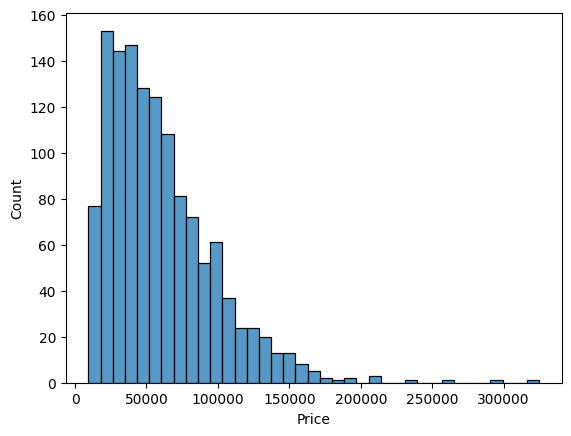

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'])
plt.show()

In [7]:
df['Cpu'].value_counts().head(20)

Cpu
Intel Core i5 7200U 2.5GHz              190
Intel Core i7 7700HQ 2.8GHz             146
Intel Core i7 7500U 2.7GHz              134
Intel Core i7 8550U 1.8GHz               73
Intel Core i5 8250U 1.6GHz               72
Intel Core i5 6200U 2.3GHz               68
Intel Core i3 6006U 2GHz                 64
Intel Core i7 6500U 2.5GHz               49
Intel Core i7 6700HQ 2.6GHz              43
Intel Core i3 7100U 2.4GHz               37
Intel Core i5 7300HQ 2.5GHz              33
Intel Celeron Dual Core N3350 1.1GHz     30
Intel Celeron Dual Core N3060 1.6GHz     28
Intel Core i7 6600U 2.6GHz               18
Intel Core i3 6006U 2.0GHz               16
Intel Pentium Quad Core N4200 1.1GHz     14
Intel Core i5 7300U 2.6GHz               14
Intel Core i7 7600U 2.8GHz               13
Intel Pentium Quad Core N3710 1.6GHz     11
AMD A9-Series 9420 3GHz                  11
Name: count, dtype: int64

In [8]:
df['Cpu Name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]))

df[['Cpu','Cpu Name']].head()

,Cpu,Cpu Name
0,Intel Core i5 2.3GHz,Intel Core i5
1,Intel Core i5 1.8GHz,Intel Core i5
2,Intel Core i5 7200U 2.5GHz,Intel Core i5
3,Intel Core i7 2.7GHz,Intel Core i7
4,Intel Core i5 3.1GHz,Intel Core i5


In [9]:
df['Cpu Name'].value_counts()

Cpu Name
Intel Core i7               527
Intel Core i5               423
Intel Core i3               136
Intel Celeron Dual           80
Intel Pentium Quad           27
Intel Core M                 19
AMD A9-Series 9420           12
AMD A6-Series 9220            8
Intel Celeron Quad            8
AMD A12-Series 9720P          7
Intel Atom x5-Z8350           5
AMD A8-Series 7410            4
Intel Atom x5-Z8550           4
AMD A9-Series 9410            3
Intel Pentium Dual            3
AMD Ryzen 1700                3
AMD A9-Series A9-9420         2
AMD E-Series E2-9000e         2
AMD A10-Series A10-9620P      2
AMD A6-Series A6-9220         2
AMD E-Series 7110             2
AMD A10-Series 9620P          2
AMD A10-Series 9600P          2
Intel Xeon E3-1505M           2
Intel Xeon E3-1535M           2
Intel Atom X5-Z8350           2
Intel Atom x5-Z8300           1
AMD E-Series 6110             1
AMD E-Series 9000e            1
AMD E-Series E2-6110          1
AMD FX 9830P                  1

In [13]:
def fetch_processor(text):
    
    if text == 'Intel Core i3':
        return 'Intel Core i3'
    
    elif text == 'Intel Core i5':
        return 'Intel Core i5'
    
    elif text == 'Intel Core i7':
        return 'Intel Core i7'
    
    elif text == 'Intel Core M':
        return 'Intel Core M'
    
    elif text.startswith('Intel'):
        return 'Other Intel Processor'
    
    else:
        return 'AMD Processor'



In [15]:
df['Cpu Brand'] = df['Cpu Name'].apply(fetch_processor)

df['Cpu Brand'].value_counts()

Cpu Brand
Intel Core i7            527
Intel Core i5            423
Intel Core i3            136
Other Intel Processor    135
AMD Processor             63
Intel Core M              19
Name: count, dtype: int64

In [16]:
# see touch screen is or not
df['Touchscreen'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'Touchscreen' in x else 0
)

df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

In [17]:
df['IPS'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'IPS' in x else 0
)

df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

In [18]:
df['ScreenResolution'].str.split().str[-1].head()

0    2560x1600
1     1440x900
2    1920x1080
3    2880x1800
4    2560x1600
Name: ScreenResolution, dtype: object

Extract X_res and Y_res

In [21]:
new = df['ScreenResolution'].str.split().str[-1]

df['X_res'] = new.str.split('x').str[0]
df['Y_res'] = new.str.split('x').str[1]

df[['ScreenResolution','X_res','Y_res']].head()

,ScreenResolution,X_res,Y_res
0,IPS Panel Retina Display 2560x1600,2560,1600
1,1440x900,1440,900
2,Full HD 1920x1080,1920,1080
3,IPS Panel Retina Display 2880x1800,2880,1800
4,IPS Panel Retina Display 2560x1600,2560,1600


In [22]:
df['X_res'] = df['X_res'].astype(int)
df['Y_res'] = df['Y_res'].astype(int)

df[['X_res','Y_res']].dtypes

X_res    int64
Y_res    int64
dtype: object

What is PPI?

Pixels Per Inch = Screen kitni sharp hai.


In [23]:
import numpy as np

df['ppi'] = (
    np.sqrt(df['X_res']**2 + df['Y_res']**2)
    / df['Inches']
)

df['ppi'].head()

0    226.983005
1    127.677940
2    141.211998
3    220.534624
4    226.983005
Name: ppi, dtype: float64

In [24]:
df.drop(columns=['ScreenResolution','X_res','Y_res'], inplace=True)

In [25]:
df['Memory'].value_counts().head(20)

Memory
256GB SSD               412
1TB HDD                 223
500GB HDD               132
512GB SSD               118
128GB SSD +  1TB HDD     94
128GB SSD                76
256GB SSD +  1TB HDD     73
32GB Flash Storage       38
2TB HDD                  16
64GB Flash Storage       15
1TB SSD                  14
512GB SSD +  1TB HDD     14
256GB SSD +  2TB HDD     10
1.0TB Hybrid              9
256GB Flash Storage       8
16GB Flash Storage        7
32GB SSD                  6
180GB SSD                 5
128GB Flash Storage       4
16GB SSD                  3
Name: count, dtype: int64

In [26]:
df[df['Memory'].str.contains('TB')]['Memory'].head(20)

18                 1TB HDD
21    128GB SSD +  1TB HDD
25                 1TB HDD
29                 1TB HDD
36                 1TB HDD
37    128GB SSD +  1TB HDD
38                 1TB HDD
40                 1TB HDD
41    256GB SSD +  1TB HDD
42                 1TB HDD
44                 1TB HDD
47    256GB SSD +  1TB HDD
49                 1TB HDD
54                 1TB HDD
58    256GB SSD +  2TB HDD
60    256GB SSD +  2TB HDD
68                 1TB HDD
69                 1TB HDD
73    128GB SSD +  1TB HDD
74                 1TB HDD
Name: Memory, dtype: object

In [28]:
#conver TB into gb
df['Memory'] = df['Memory'].str.replace('TB', '000GB')
df['Memory'].head(10)

0              128GB SSD
1    128GB Flash Storage
2              256GB SSD
3              512GB SSD
4              256GB SSD
5              500GB HDD
6    256GB Flash Storage
7    256GB Flash Storage
8              512GB SSD
9              256GB SSD
Name: Memory, dtype: object

In [29]:
# Convert Memory column to string so string operations can be applied
df['Memory'] = df['Memory'].astype(str)

# Remove '.0' from values like '1.0TB' and convert TB into GB format
df['Memory'] = df['Memory'].str.replace('.0', '', regex=False)
df['Memory'] = df['Memory'].str.replace('TB', '000GB')

In [30]:
df['Memory'].sample(10)

1170                  256GB SSD
339                   256GB SSD
713          32GB Flash Storage
485                   256GB SSD
518                   256GB SSD
971                   256GB SSD
596                   512GB SSD
1214    256GB SSD +  1000GB HDD
508                   512GB SSD
194                  1000GB HDD
Name: Memory, dtype: object

In [31]:
# Split Memory column into first and second storage devices
new = df['Memory'].str.split('+', n=1, expand=True)

# Store first storage device
df['first'] = new[0]

# Store second storage device
df['second'] = new[1]

# Replace missing second storage values with 0
df['second'] = df['second'].fillna('0')

In [32]:
df[['Memory','first','second']].sample(10)

,Memory,first,second
765,128GB SSD,128GB SSD,0
571,2000GB HDD,2000GB HDD,0
485,256GB SSD,256GB SSD,0
774,256GB SSD,256GB SSD,0
1046,256GB SSD,256GB SSD,0
862,128GB SSD,128GB SSD,0
1293,1000GB HDD,1000GB HDD,0
185,512GB SSD,512GB SSD,0
1146,256GB SSD,256GB SSD,0
199,256GB SSD,256GB SSD,0


In [33]:
# Create flags for storage types in first drive
df['Layer1HDD'] = df['first'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Layer1SSD'] = df['first'].apply(lambda x: 1 if 'SSD' in x else 0)
df['Layer1Hybrid'] = df['first'].apply(lambda x: 1 if 'Hybrid' in x else 0)
df['Layer1Flash'] = df['first'].apply(lambda x: 1 if 'Flash Storage' in x else 0)

In [34]:
# Extract only numeric storage size from first drive
df['first'] = df['first'].str.extract('(\d+)')
df['first'] = df['first'].astype(int)

256GB SSD
↓
256

1000GB HDD
↓
1000

In [35]:
df[['first','Layer1HDD','Layer1SSD','Layer1Hybrid','Layer1Flash']].head(10)

,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash
0,128,0,1,0,0
1,128,0,0,0,1
2,256,0,1,0,0
3,512,0,1,0,0
4,256,0,1,0,0
5,500,1,0,0,0
6,256,0,0,0,1
7,256,0,0,0,1
8,512,0,1,0,0
9,256,0,1,0,0


In [36]:
# Create flags for storage types in second drive
df['Layer2HDD'] = df['second'].apply(lambda x: 1 if 'HDD' in x else 0)
df['Layer2SSD'] = df['second'].apply(lambda x: 1 if 'SSD' in x else 0)
df['Layer2Hybrid'] = df['second'].apply(lambda x: 1 if 'Hybrid' in x else 0)
df['Layer2Flash'] = df['second'].apply(lambda x: 1 if 'Flash Storage' in x else 0)

In [37]:
# Extract numeric storage size from second drive
df['second'] = df['second'].str.extract('(\d+)')

# Replace missing values with 0
df['second'] = df['second'].fillna(0)

# Convert to integer
df['second'] = df['second'].astype(int)

In [38]:
df[['second','Layer2HDD','Layer2SSD','Layer2Hybrid','Layer2Flash']].sample(10)

,second,Layer2HDD,Layer2SSD,Layer2Hybrid,Layer2Flash
1030,0,0,0,0,0
583,0,0,0,0,0
38,0,0,0,0,0
300,0,0,0,0,0
568,0,0,0,0,0
457,0,0,0,0,0
758,1000,1,0,0,0
248,0,0,0,0,0
1158,0,0,0,0,0
798,0,0,0,0,0


In [39]:
# Calculate total HDD storage in GB
df['HDD'] = (df['first'] * df['Layer1HDD']) + (df['second'] * df['Layer2HDD'])

# Calculate total SSD storage in GB
df['SSD'] = (df['first'] * df['Layer1SSD']) + (df['second'] * df['Layer2SSD'])

# Calculate total Hybrid storage in GB
df['Hybrid'] = (df['first'] * df['Layer1Hybrid']) + (df['second'] * df['Layer2Hybrid'])

# Calculate total Flash Storage in GB
df['Flash_Storage'] = (df['first'] * df['Layer1Flash']) + (df['second'] * df['Layer2Flash'])

Example

For:

256GB SSD + 1000GB HDD

Result:

SSD = 256
HDD = 1000
Hybrid = 0
Flash_Storage = 0

In [40]:
df[['HDD','SSD','Hybrid','Flash_Storage']].sample(10)

,HDD,SSD,Hybrid,Flash_Storage
635,1000,0,0,0
240,0,128,0,0
1298,0,128,0,0
1103,1000,0,0,0
1050,0,256,0,0
333,1000,0,0,0
819,500,0,0,0
813,1000,0,0,0
638,0,256,0,0
571,2000,0,0,0


In [41]:
# Remove intermediate columns used for memory processing
df.drop(columns=[
    'Memory',
    'first',
    'second',
    'Layer1HDD',
    'Layer1SSD',
    'Layer1Hybrid',
    'Layer1Flash',
    'Layer2HDD',
    'Layer2SSD',
    'Layer2Hybrid',
    'Layer2Flash'
], inplace=True)


In [42]:
df.head()
df.columns

Index(['Company', 'TypeName', 'Inches', 'Cpu', 'Ram', 'Gpu', 'OpSys', 'Weight',
       'Price', 'Cpu Name', 'Cpu Brand', 'Touchscreen', 'IPS', 'ppi', 'HDD',
       'SSD', 'Hybrid', 'Flash_Storage'],
      dtype='object')

In [43]:
# Step 11: GPU Feature Engineering



df['Gpu'].apply(lambda x: x.split()[0]).value_counts()

Gpu
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [46]:
# Extract GPU manufacturer from Gpu column
df['Gpu Brand'] = df['Gpu'].apply(lambda x: x.split()[0])

# Remove original Gpu column
df.drop(columns=['Gpu'], inplace=True)

In [47]:
df[['Gpu Brand']].head()
df['Gpu Brand'].value_counts()

Gpu Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [48]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [49]:
# Categorize operating systems into broader groups
def categorize_os(text):

    if text == 'Windows 10' or text == 'Windows 7' or text == 'Windows 10 S':
        return 'Windows'

    elif text == 'macOS' or text == 'Mac OS X':
        return 'Mac'

    elif text == 'Linux':
        return 'Linux'

    elif text == 'No OS':
        return 'No OS'

    else:
        return 'Others'

In [50]:
df['OS'] = df['OpSys'].apply(categorize_os)

In [51]:
df['OS'].value_counts()

OS
Windows    1125
No OS        66
Linux        62
Others       29
Mac          21
Name: count, dtype: int64

In [52]:
df.drop(columns=['OpSys'], inplace=True)

<Axes: xlabel='Price', ylabel='Count'>

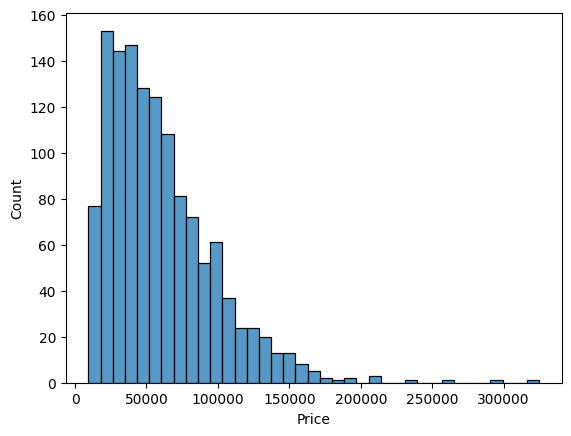

In [53]:
import seaborn as sns
sns.histplot(df['Price'])

In [54]:
df[['Cpu','Cpu Name','Cpu Brand']].head()

,Cpu,Cpu Name,Cpu Brand
0,Intel Core i5 2.3GHz,Intel Core i5,Intel Core i5
1,Intel Core i5 1.8GHz,Intel Core i5,Intel Core i5
2,Intel Core i5 7200U 2.5GHz,Intel Core i5,Intel Core i5
3,Intel Core i7 2.7GHz,Intel Core i7,Intel Core i7
4,Intel Core i5 3.1GHz,Intel Core i5,Intel Core i5


In [ ]:
df.drop(columns=['Cpu', 'Cpu Name'], inplace=True)

In [60]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Price', 'Cpu Brand',
       'Touchscreen', 'IPS', 'ppi', 'HDD', 'SSD', 'Hybrid', 'Flash_Storage',
       'Gpu Brand', 'OS'],
      dtype='object')

In [61]:
df.shape

(1303, 16)

In [62]:
X.head

NameError: name 'X' is not defined

In [63]:
import numpy as np

X = df.drop(columns=['Price'])
y = np.log(df['Price'])

In [64]:
df.shape

(1303, 16)

In [66]:
df.columns


Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Price', 'Cpu Brand',
       'Touchscreen', 'IPS', 'ppi', 'HDD', 'SSD', 'Hybrid', 'Flash_Storage',
       'Gpu Brand', 'OS'],
      dtype='object')

In [70]:
X = df.drop(columns=['Price'])
df.shape

(1303, 16)

In [71]:
X.shape

(1303, 15)

In [72]:
# Step 2: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=2
)

In [73]:
X_train.shape, X_test.shape

((1107, 15), (196, 15))

In [74]:
# Step 3: Create Preprocessor (ColumnTransformer)

# Ab categorical columns ko One-Hot Encode karenge.


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

transformer = ColumnTransformer(
    transformers=[
        ('tnf1', OneHotEncoder(drop='first'), [0, 1, 5, 13, 14])
    ],
    remainder='passthrough'
)

In [75]:
transformer

,transformers,"[('tnf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,True


In [ ]:
# Step 4: Linear Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

pipe = Pipeline([
    ('step1', transformer),
    ('step2', LinearRegression())
])

In [77]:
# : Train the Model
pipe.fit(X_train, y_train)


,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = pipe.predict(X_test)
# print(y_pred)

[10.7381077   9.70080872 11.10231606 11.32728825 11.50501338 10.50197197
 10.86094903 10.90567963  9.90366159 11.01298668 10.12391445 10.96074592
 11.37741974 10.92057793 10.89467219 10.90763334 10.96995695 11.16896844
 10.08893111 10.88352933 11.49236781 11.4958261   9.59362471 10.42421764
 10.1967253  11.7172488  10.99823379 10.01790036 10.27145401 10.703538
 10.23399689 10.04420125  9.82634513 10.84464958 11.22716108 10.29381442
 10.92380921 10.5942242  10.9148691  11.57314179 11.23780869 10.4602718
 10.43572136 11.67173412 11.61689557 10.16355735 10.97351395 10.24913925
  9.8703535   9.93894561 10.94792375  9.83301332 11.15782849 11.04783955
 11.20569892 10.65318819 11.52402493 10.79736179 10.20947104 11.94275498
 10.95449931 11.97606419  9.79146867 11.06123675 10.81825089 11.2154244
  9.94999031  9.85979399 10.76580805 11.06827128 10.95494731 10.76041845
 10.67926362  9.92558162 10.59171011 10.6860109  10.75596976 10.42316331
 10.78158937 10.47003597  9.67648432  9.84626854 10.658

In [80]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.8397782351484426
MAE: 11819.730125018557


In [82]:
# trying with other model also
from sklearn.linear_model import Ridge
pipe = Pipeline([
    ('step1', transformer),
    ('step2', Ridge(alpha=10))
])
pipe.fit(X_train, y_train)

,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [83]:
y_pred = pipe.predict(X_test)

In [84]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.8366175774069708
MAE: 11909.000017601127


In [85]:
#try other model
from sklearn.linear_model import Lasso
pipe = Pipeline([
    ('step1', transformer),
    ('step2', Lasso(alpha=0.001))
])
pipe.fit(X_train, y_train)

,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [86]:
y_pred = pipe.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.8357563890057196
MAE: 12120.2547020441


In [87]:
#tring other model
from sklearn.tree import DecisionTreeRegressor
pipe = Pipeline([
    ('step1', transformer),
    ('step2', DecisionTreeRegressor(random_state=2))
])
pipe.fit(X_train, y_train)

,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
y_pred = pipe.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.80324743329775
MAE: 11407.146660925473


In [89]:
# trying woth other model
from sklearn.ensemble import RandomForestRegressor
pipe = Pipeline([
    ('step1', transformer),
    ('step2', RandomForestRegressor(
        n_estimators=100,
        random_state=2,
        max_samples=0.5,
        max_features=0.75,
        max_depth=15
    ))
])
pipe.fit(X_train, y_train)

,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('tnf1', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
y_pred = pipe.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.891927405936533
MAE: 9093.88587890394


In [96]:
# trying another model also
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

pipe = Pipeline([
    ('step1', transformer),
    ('step2', ExtraTreesRegressor(
        n_estimators=100,
        random_state=2,
        max_features=0.75,
        max_depth=15
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))



R2 Score: 0.8811712796726192
MAE: 9085.357059737642


In [97]:
# ab gradient booster laga rhe h e
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

pipe = Pipeline([
    ('step1', transformer),
    ('step2', GradientBoostingRegressor(
        n_estimators=500
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.898879954347155
MAE: 8825.705396264755


In [98]:
import xgboost
print(xgboost.__version__)

3.2.0


In [99]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

pipe = Pipeline([
    ('step1', transformer),
    ('step2', XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=2
    ))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(np.exp(y_test), np.exp(y_pred)))

R2 Score: 0.9076047997937937
MAE: 8183.6262977519145


In [100]:
import pickle

pickle.dump(df, open('df.pkl', 'wb'))
pickle.dump(pipe, open('pipe.pkl', 'wb'))


# df.pkl → dataset structure for Streamlit dropdowns
# pipe.pkl → trained XGBoost model